# Creación de figuras para análisis bivariable

## 1) Heatmap o mapa de calor

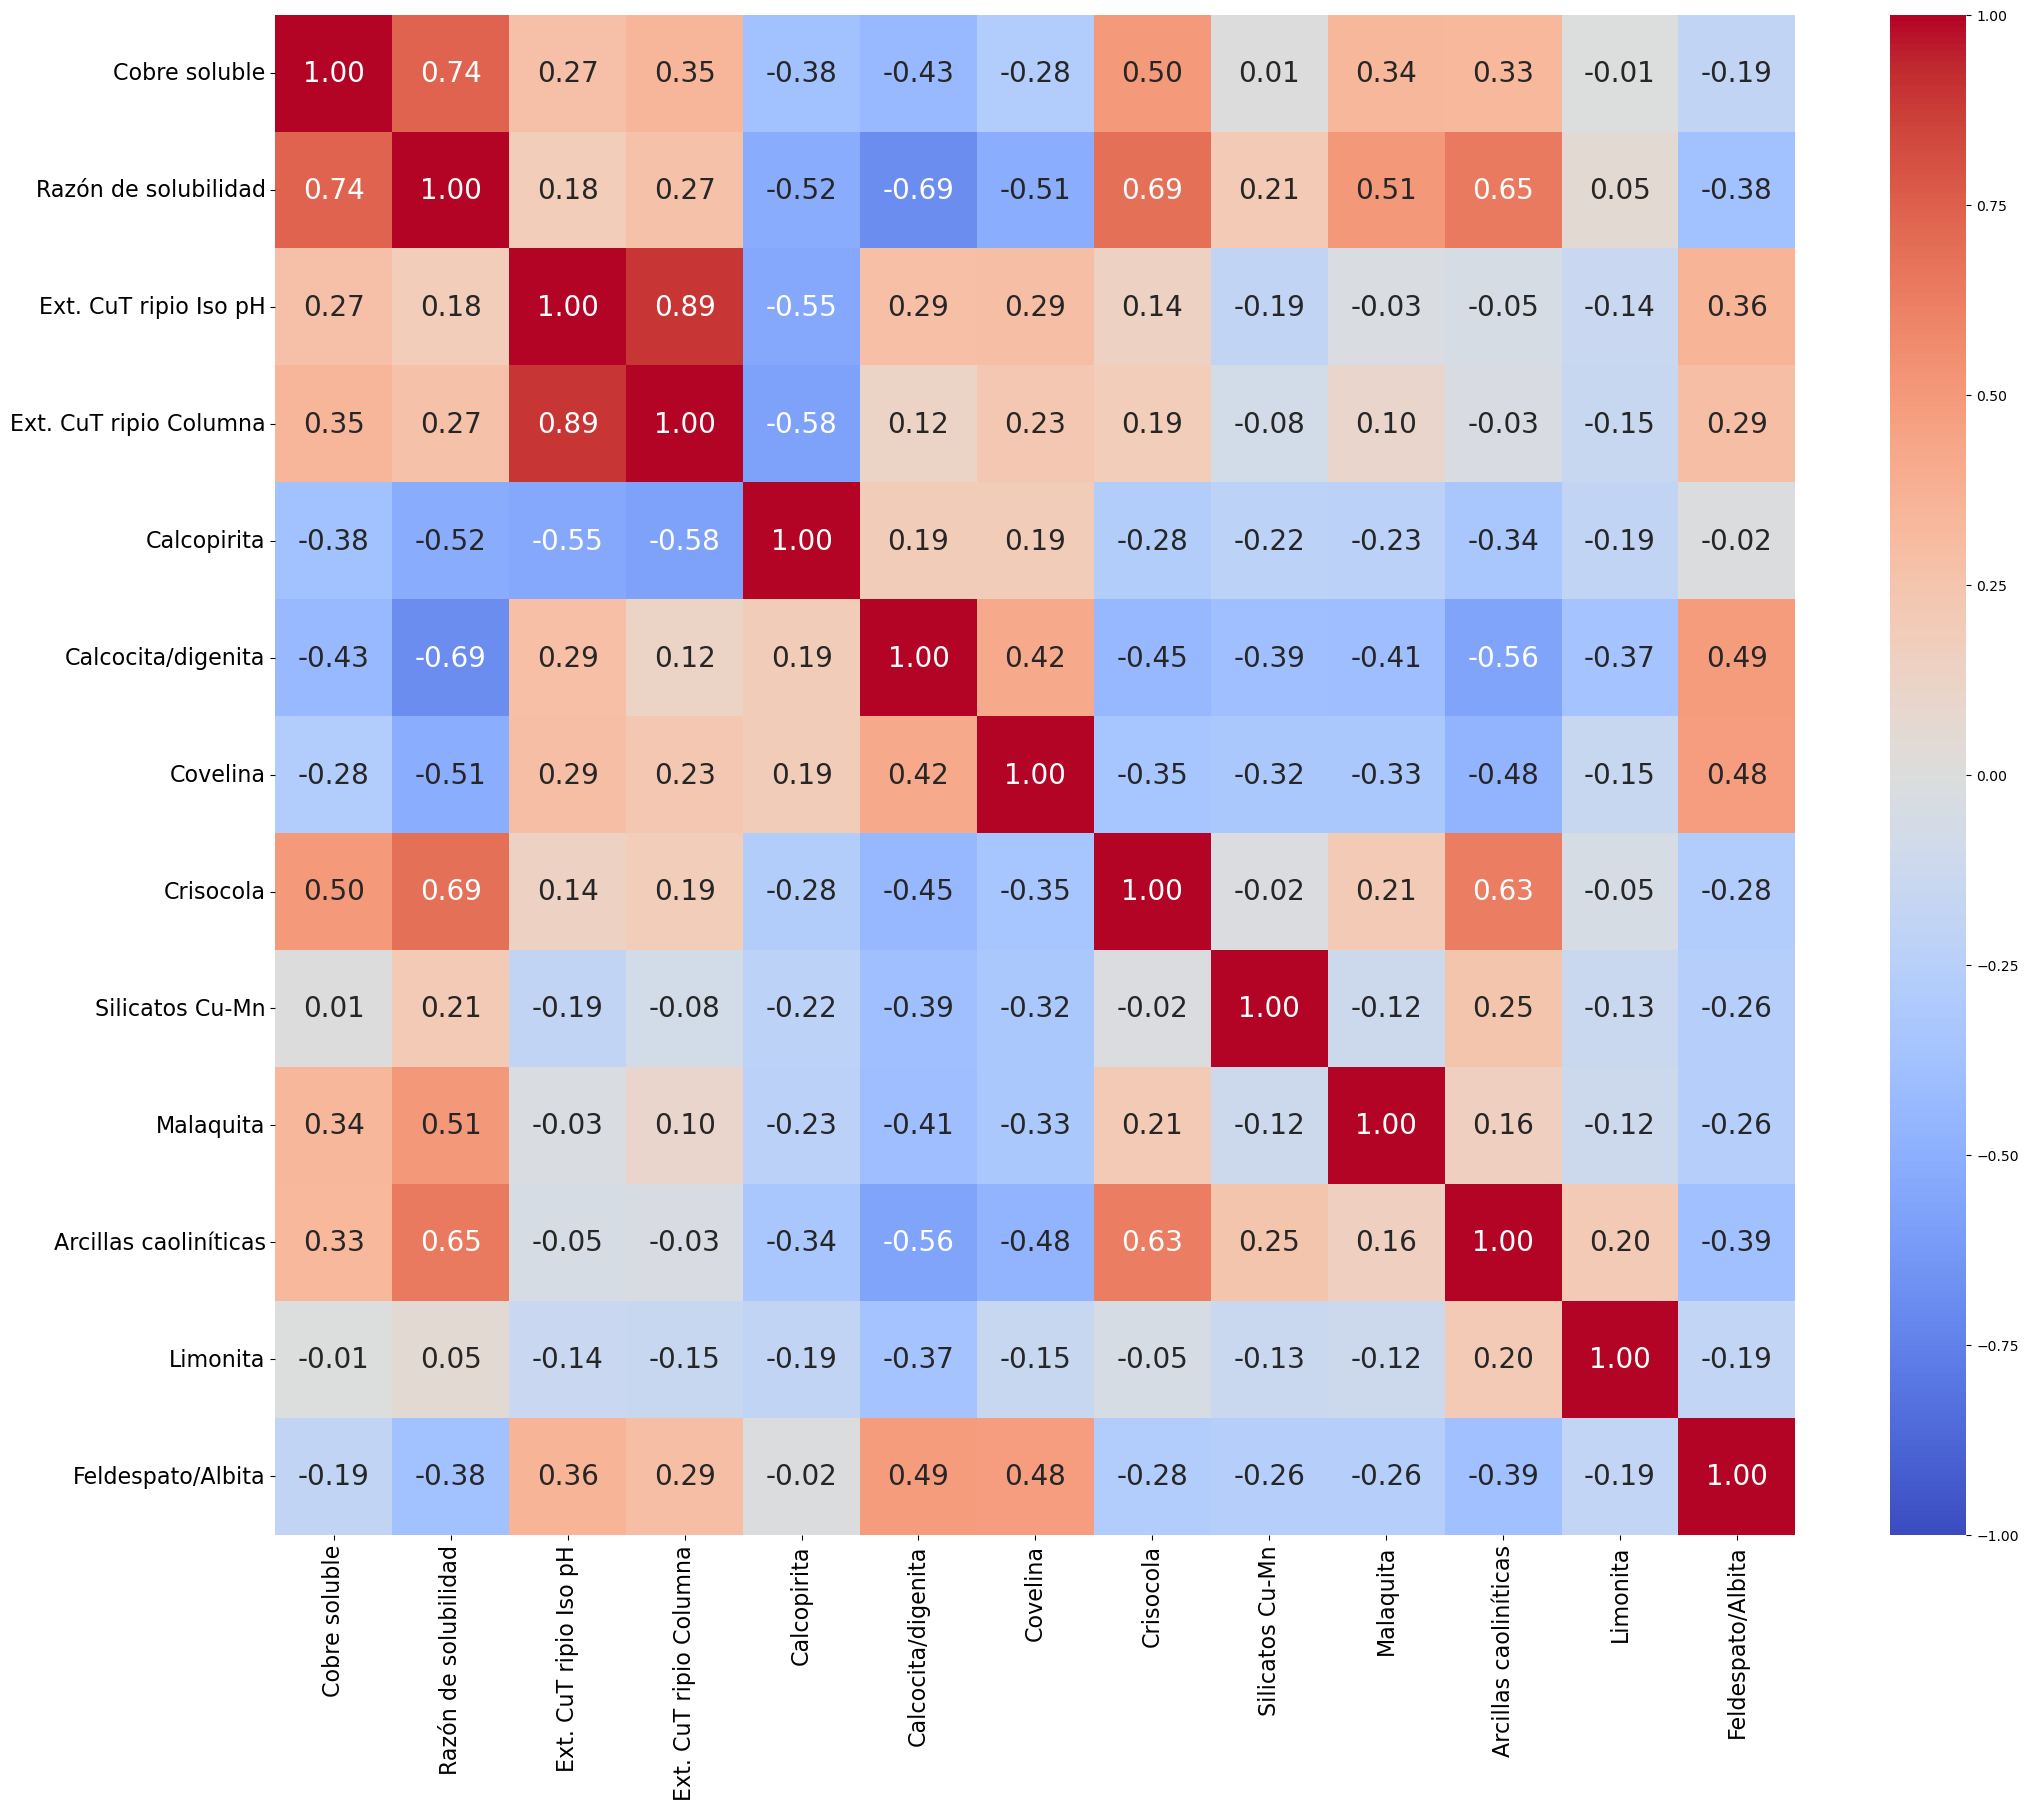

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

columnas_deseadas=['cu_s','rs_aj',
    'ext_cut_rip_ph','ext_cut_rip_selec_col','cpy_base_ley_cu','ch_dig_base_ley_cu',
    'cv_base_ley_cu','ccl_base_ley_cu','p_mch_base_ley_cu',
    'cu_mn_silicates_base_ley_cu','cu_kaoli_clay_base_ley_cu',
    'lim_base_ley_cu','feld_alb_base_ley_cu'
]

excelPath = r"C:\Users\Diego\Desktop\Ultimo Esfuerzo\Copia de Base de Datos Cuprochlor Sin T Final.xlsx"
dataframe = pd.read_excel(excelPath, "BD elim y reducido", usecols=columnas_deseadas)

rename_map = {
    "cu_s": "Cobre soluble",
    "rs_aj": "Razón de solubilidad",
    "ext_cut_rip_ph": "Ext. CuT ripio Iso pH",
    "ext_cut_rip_selec_col": "Ext. CuT ripio Columna",
    "cpy_base_ley_cu": "Calcopirita",
    "ch_dig_base_ley_cu": "Calcocita/digenita",
    "cv_base_ley_cu": "Covelina",
    "ccl_base_ley_cu": "Crisocola",
    "p_mch_base_ley_cu": "Malaquita",
    "cu_mn_silicates_base_ley_cu": "Silicatos Cu-Mn",
    "cu_kaoli_clay_base_ley_cu": "Arcillas caoliníticas",
    "lim_base_ley_cu": "Limonita",
    "feld_alb_base_ley_cu": "Feldespato/Albita"
}
dataframe = dataframe.rename(columns=rename_map)

corr_matrix = dataframe.corr()

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1, vmin=-1,
    annot_kws={"size": 20}
)

# ======= AUMENTAR TAMAÑO ETIQUETAS X e Y =======
ax.tick_params(axis='x', labelsize=16, rotation=90)
ax.tick_params(axis='y', labelsize=16, rotation=0)
# ===============================================

plt.subplots_adjust(left=0.1, right=2, top=2, bottom=0.1)
plt.savefig(r"C:\Users\Diego\Desktop\Ultimo Esfuerzo\heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 2) Pairplot multivariable

In [6]:
columnas_deseadas=[  #En esta variable, se agregan los nombres de las columnas que deseamos
                   'ext_cut_rip_ph',                # Extraccion de cobre total pruebas iso ph
                   'ext_cut_rip_selec_col',         # Extraccion de cobre total pruebas en columna seleccionada
                   'cut_cbz',                       # Ley de cobre cabeza
                   'rs_aj',                         # Razon de solubilidad
                   'cu_s',                         # Contabilidad metalurgica pruebas iso ph
                   'rs_aj','Zona Min' ]                  
excelPath=r"C:\Users\Diego\Desktop\Ultimo Esfuerzo\Copia de Base de Datos Cuprochlor Sin T Final.xlsx" #Ingregamos la ubicación del excel a trabajar

dataframe=pd.read_excel(excelPath,"BD elim y reducido (2)",usecols=columnas_deseadas) 
#en dataframe utilizando pd.read_Excel, utilizamos el excel ya mencionado y seleccionamos la hoja

df2=dataframe  #Asignamos la informacion a la variable df

In [8]:
labels = {
    "cut_cbz": "Ley de Cobre [%]",
    "cu_s": "Cobre Soluble [%]",
    "rs_aj": "Razón de Solubilidad [%]",
    "ext_cut_rip_ph": "Extracción Iso pH [%]",
    "ext_cut_rip_selec_col": "Extracción Columna [%]"
}

In [10]:
df2_plot = df2.rename(columns=labels).copy()

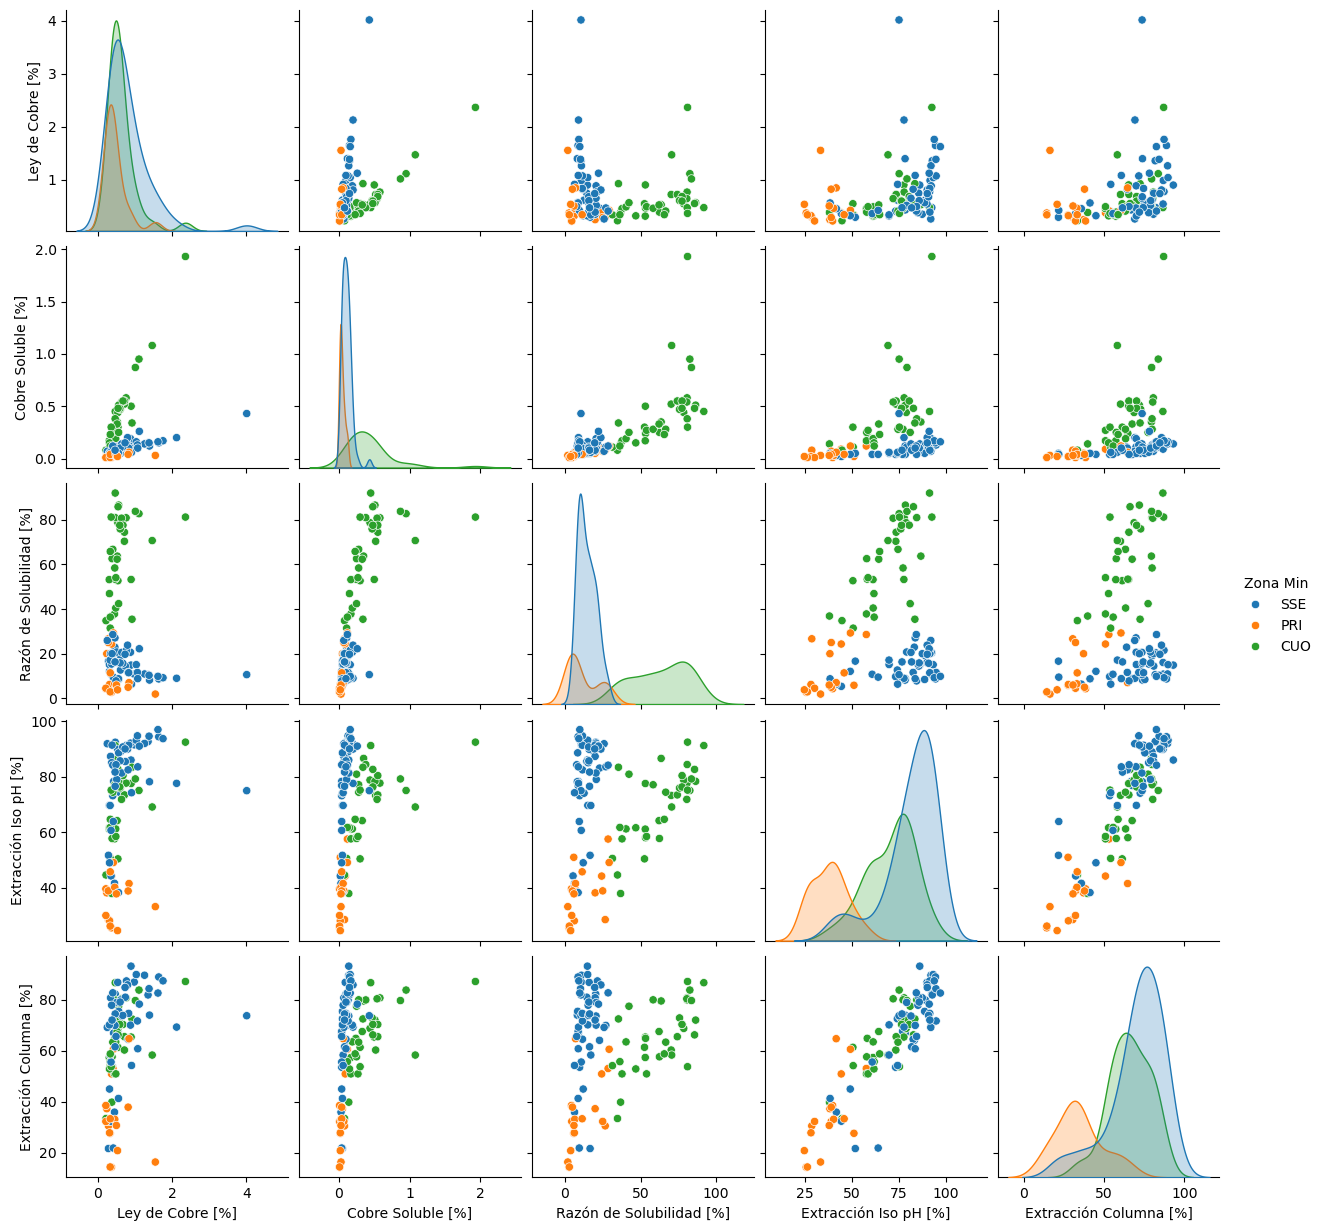

In [12]:
sns.pairplot(df2_plot, hue='Zona Min')

plt.savefig(
    "pairplotmulti.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()